## DAY 1 : POSITIONAL ENCODING

In [1]:
import numpy as np
import torch
import sys
import os
import json

import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
sys.path.append(os.path.abspath('..'))

In [ ]:
from src.positional_encoding import PositonalEncoding
from src.attention import MultiHeadAttention

In [3]:
batch_size = 32
seq_len = 5
d_model = 512


X = torch.randn(batch_size, seq_len, d_model)
print(f"Input X shape: {X.shape}")

Input X shape: torch.Size([32, 5, 512])


In [4]:
pe = PositonalEncoding(5000,d_model)

output = pe.forward(X)

print(output.shape)

torch.Size([32, 5, 512])


### Visualization

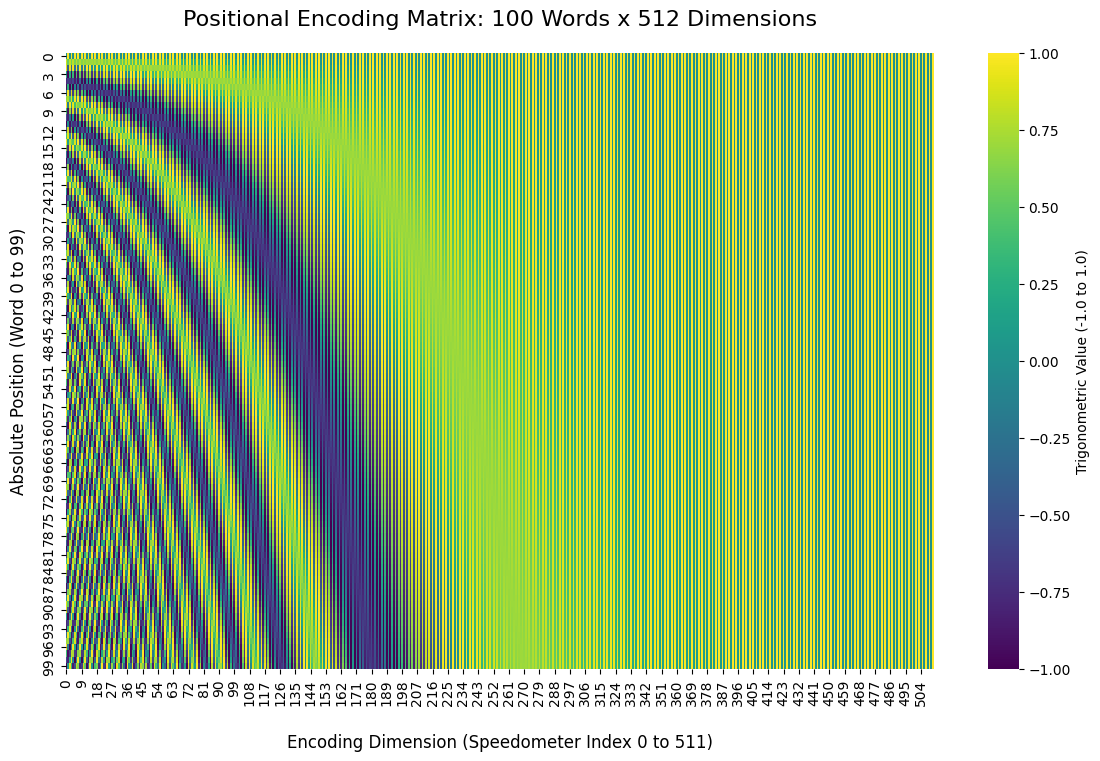

In [5]:
os.makedirs('./../experiments', exist_ok=True)

matrix_to_plot = pe.pe[:100, :].numpy()

plt.figure(figsize=(14, 8))


# cmap='viridis' ensures it remains colorblind-friendly
# cbar_kws adds a label to the color scale on the right
sns.heatmap(matrix_to_plot, 
            cmap='viridis', 
            cbar_kws={'label': 'Trigonometric Value (-1.0 to 1.0)'})

#  Apply rigorous, professional labels
plt.title("Positional Encoding Matrix: 100 Words x 512 Dimensions", fontsize=16, pad=20)
plt.xlabel("Encoding Dimension (Speedometer Index 0 to 511)", fontsize=12, labelpad=20)
plt.ylabel("Absolute Position (Word 0 to 99)", fontsize=12, labelpad=10)

plt.savefig('./../experiments/positional_encoding_plot.png', dpi=300, bbox_inches='tight')

plt.show()

## DAY 2: Multi-Head Attention

In [6]:
batch_size = 32
seq_len = 5
d_model = 512


X = torch.randn(batch_size, seq_len, d_model)
print(f"Input X shape: {X.shape}")

Input X shape: torch.Size([32, 5, 512])


In [8]:
mh = MultiHeadAttention(512,8)

output,weights = mh.forward(X)


print(output.shape)
print(f"Weights shape is {weights.shape}")


sums = torch.sum(weights, dim=-1)
print(sums)

Q shape before head splitting torch.Size([32, 5, 512])
Q shape after head splitting torch.Size([32, 8, 5, 64])
K shape before head splitting torch.Size([32, 5, 512])
K shape after head splitting torch.Size([32, 8, 5, 64])
V shape before head splitting torch.Size([32, 5, 512])
V shape after head splitting torch.Size([32, 8, 5, 64])
torch.Size([32, 5, 512])
Weights shape is torch.Size([32, 8, 5, 5])
tensor([[[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]],

        [[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         ...,
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
         [1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        